**QUESTION 1 AND 2**

In [ ]:
!pip install opencv-python

In [ ]:
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
!wget https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names

--2025-04-02 18:55:07--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  13.8MB/s    in 19s     

2025-04-02 18:55:26 (12.7 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2025-04-02 18:55:27--  https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg [following]
--2025-04-02 18:55:27--  https://github.com/pjreddie/darknet/raw/refs/heads/master/cfg/yolov3.cfg
Reusing existing connection to github.com:443.

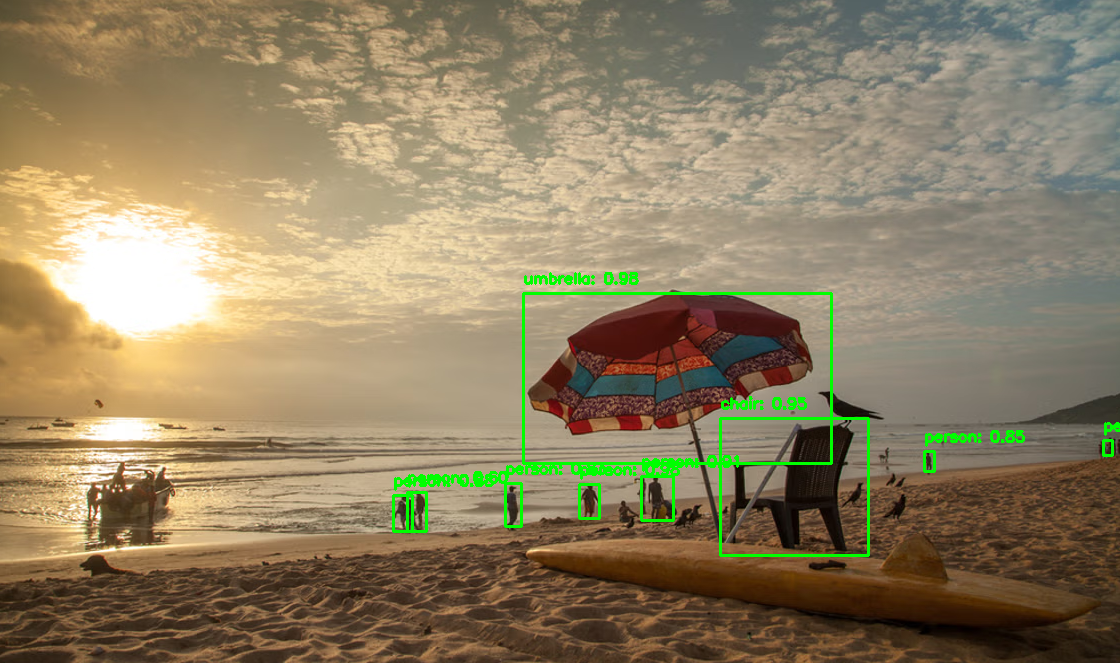

In [ ]:
# Load YOLO
net = cv2.dnn.readNet("/content/yolov3.weights", "/content/yolov3.cfg")
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Load COCO class labels
with open("/content/coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Load Image
image = cv2.imread("/content/Calangute beach goa.png")  # Change to your image
height, width, _ = image.shape

# YOLO Forward Pass
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Extract information
class_ids, confidences, boxes = [], [], []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            center_x, center_y, w, h = (detection[:4] * np.array([width, height, width, height])).astype("int")
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply NMS
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
for i in indices.flatten():
    x, y, w, h = boxes[i]
    label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Save and Display Output
cv2.imwrite("yolo_output1.jpg", image)
cv2_imshow(image)

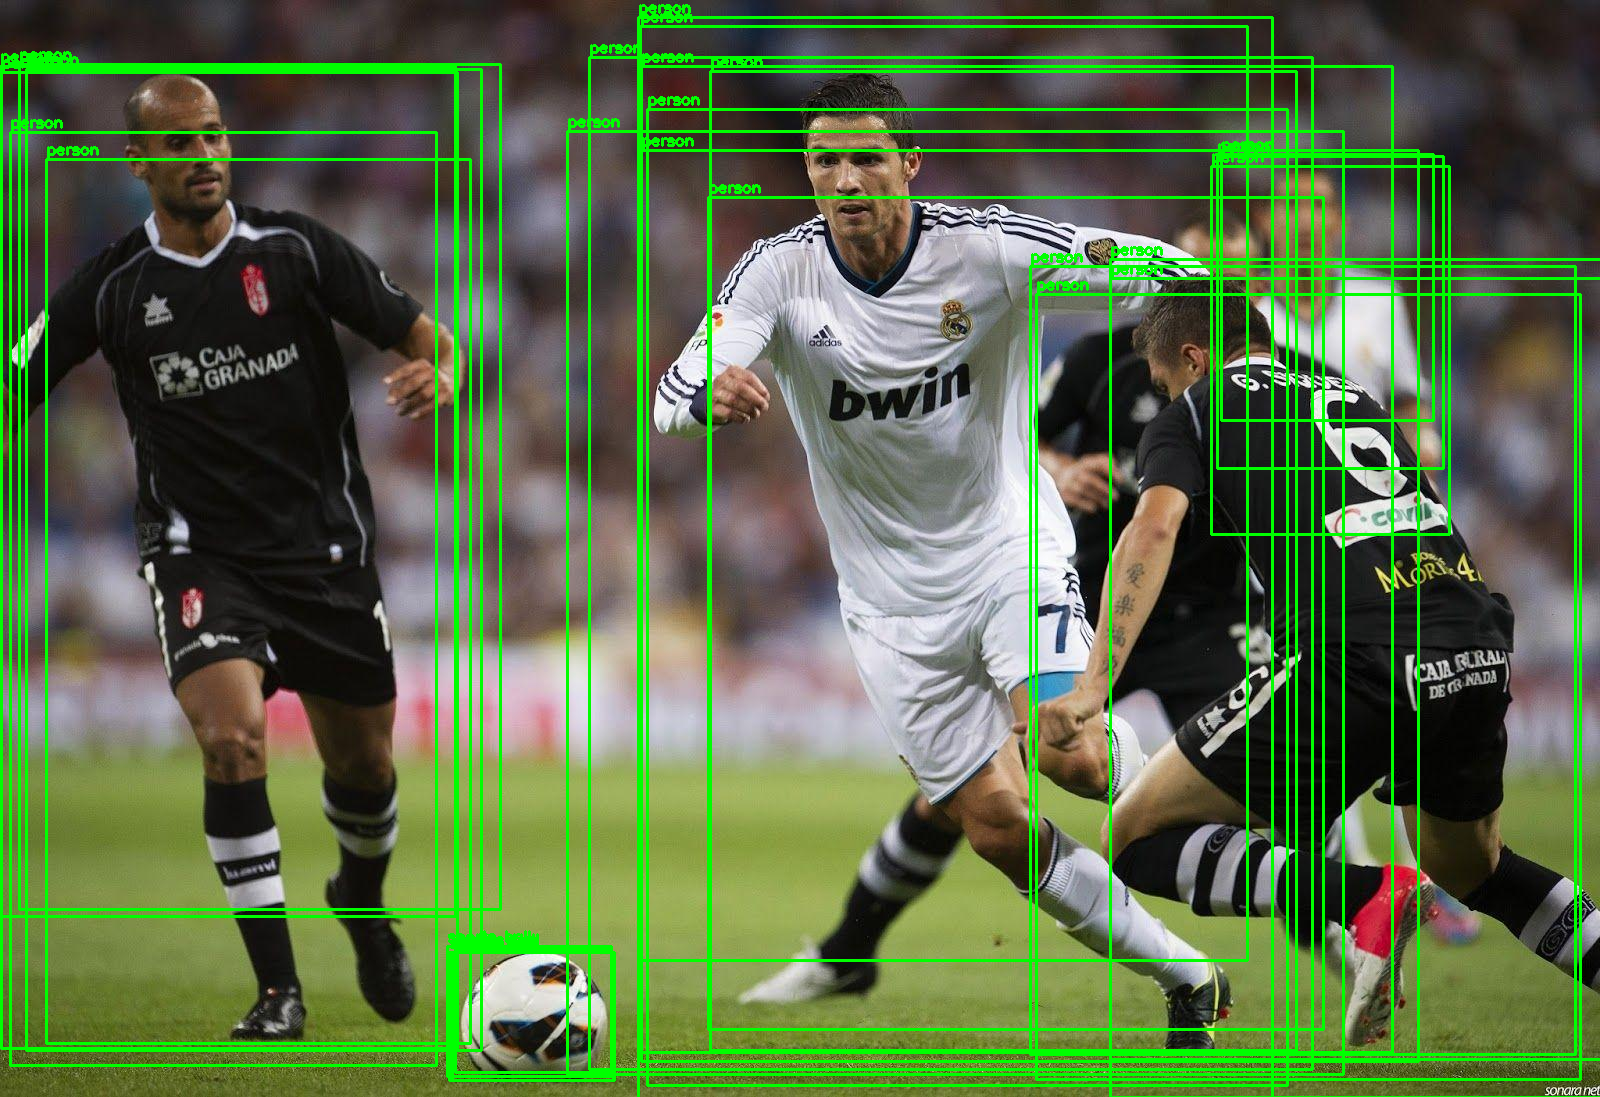

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import cv2_imshow


# Load YOLO
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
with open("coco.names", "r") as f:
    classes = f.read().strip().split("\n")

# Load image
image = cv2.imread("/content/yolodetection.jpg")
height, width, _ = image.shape

# Prepare input for YOLO
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
net.setInput(blob)
layer_names = net.getLayerNames()
# getUnconnectedOutLayers() returns an OpenCV Mat. Converting it to a NumPy array to be able to index into it properly.
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten().astype(int)] # This line is changed
detections = net.forward(output_layers)

# Process detections
for output in detections:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:  # Filter weak detections
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(image, classes[class_id], (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display output
cv2_imshow(image) # Use cv2_imshow instead of cv2.imshow
cv2.waitKey(0)
cv2.destroyAllWindows()

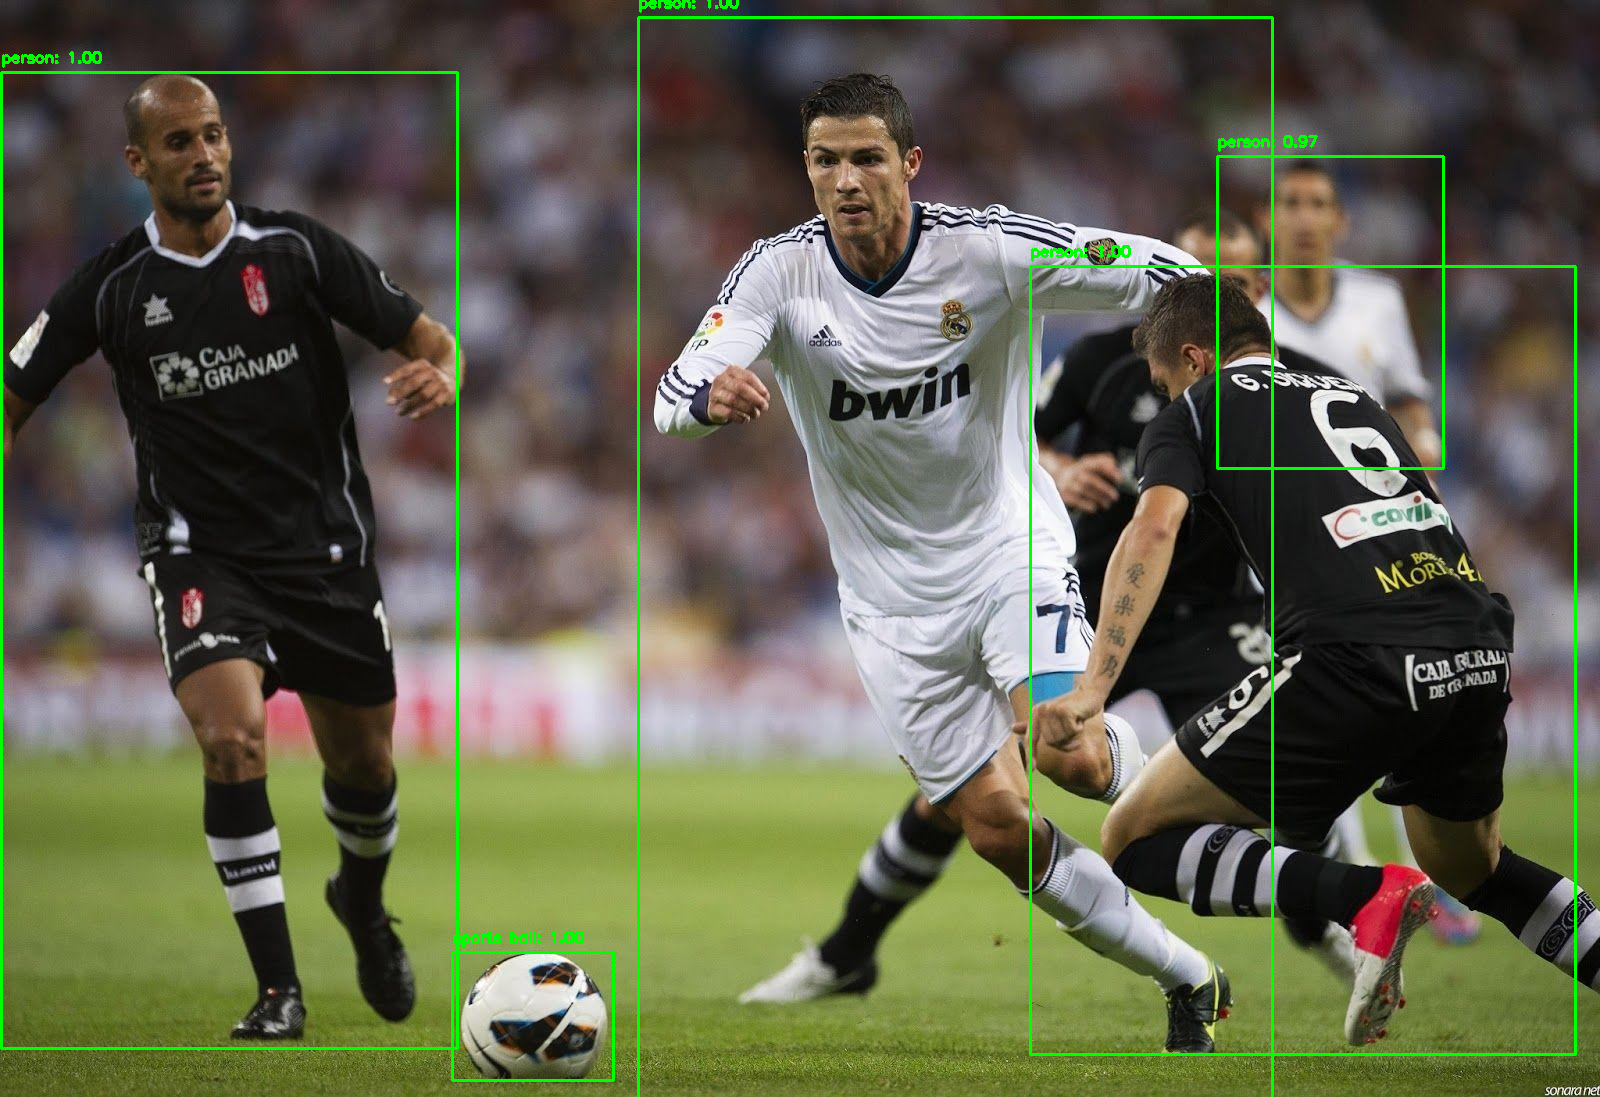

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Import for displaying images in Colab

# Load YOLO
net = cv2.dnn.readNet("/content/yolov3.weights", "/content/yolov3.cfg")
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Load COCO class labels
with open("/content/coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Load Image
image = cv2.imread("/content/yolodetection.jpg")  # Change to your image
height, width, _ = image.shape

# YOLO Forward Pass
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Extract information
class_ids, confidences, boxes = [], [], []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            center_x, center_y, w, h = (detection[:4] * np.array([width, height, width, height])).astype("int")
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply NMS
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
for i in indices.flatten():
    x, y, w, h = boxes[i]
    label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Save and Display Output
cv2.imwrite("yolo_output2.jpg", image)
cv2_imshow(image)  # Show image in Google Colab


**3. Fine-Tuning YOLO on a Custom Dataset:
a. Train a YOLOv5 model on a custom dataset using Ultralytics YOLOv5.
b. Evaluate the trained model on test images and calculate mAP (Mean Average
Precision).**

In [ ]:
# Install YOLOv5 and dependencies
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

# Verify GPU
import torch
print(f"PyTorch {torch.__version__}, GPU: {torch.cuda.is_available()}")

Cloning into 'yolov5'...
remote: Enumerating objects: 17360, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 17360 (delta 36), reused 18 (delta 18), pack-reused 17308 (from 2)
Receiving objects: 100% (17360/17360), 16.24 MiB | 14.23 MiB/s, done.
Resolving deltas: 100% (11904/11904), done.
/content/yolov5
PyTorch 2.6.0+cu124, GPU: True


In [ ]:
!pip install xmltodict tqdm


**Q5 Load a pre-trained Faster R-CNN model (e.g., from torchvision.models.detection) and
run it on a sample image.**

In [ ]:
import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Load pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set to evaluation mode


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 117MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
# Define image transformation
transform = T.Compose([
    T.ToTensor()
])

In [ ]:
# Load local image (update the path if needed)
image_path = "/content/Calangute beach goa.png"  # Change this to your actual image path
image = Image.open(image_path).convert("RGB")


In [ ]:
# Transform the image
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Perform inference
with torch.no_grad():
    predictions = model(image_tensor)


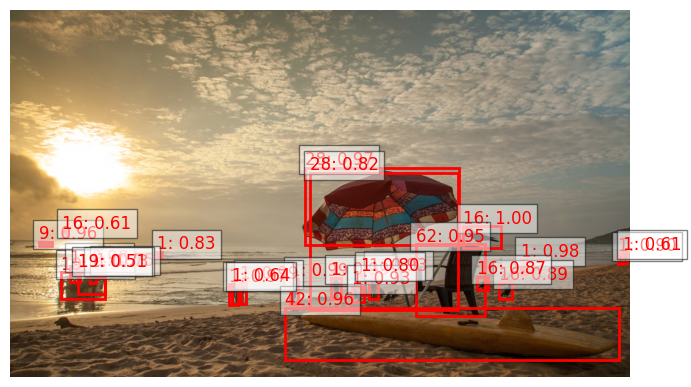

In [ ]:
# Extract results
threshold = 0.5  # Confidence threshold
boxes = predictions[0]['boxes'].numpy()
scores = predictions[0]['scores'].numpy()
labels = predictions[0]['labels'].numpy()

# Visualize results
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(image)

# Plot detected bounding boxes
for box, score, label in zip(boxes, scores, labels):
    if score > threshold:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{label}: {score:.2f}", color="red", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.axis("off")
plt.show()


**6. Fine-tuning Faster R-CNN on a Custom Dataset
a. Train Faster R-CNN on a small custom dataset (e.g., Pascal VOC or your own
annotated dataset).
b. Analyse the impact of different learning rates and batch sizes on performance.**

In [ ]:
import os
import zipfile

dataset_zip_path = "/content/drive/MyDrive/fruit_archive.zip"  # Change to your ZIP filename
dataset_path = "/content/fruits_dataset"

# Extract ZIP if the dataset is not already extracted
if not os.path.exists(dataset_path):
    os.makedirs(dataset_path)
    with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")


Dataset extracted successfully!


In [ ]:
!pip install xmltodict # Install the missing 'xmltodict' module

In [ ]:
import xmltodict
import torch
from torchvision.transforms import functional as F
from PIL import Image
import os

# Paths
datasetarchive_path='/content/fruits_dataset/fruit_archive'

train_dir = os.path.join(datasetarchive_path, "train")
test_dir = os.path.join(datasetarchive_path, "test")

# Function to load annotation from XML
def parse_voc_xml(xml_file):
    with open(xml_file) as f:
        data = xmltodict.parse(f.read())

    # Extract image info
    objects = data['annotation']['object']
    if isinstance(objects, dict):
        objects = [objects]  # Convert single object to list

    boxes = []
    labels = []
    for obj in objects:
        xmin = int(obj['bndbox']['xmin'])
        ymin = int(obj['bndbox']['ymin'])
        xmax = int(obj['bndbox']['xmax'])
        ymax = int(obj['bndbox']['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(1)  # Assuming all fruits belong to class 1

    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

# Function to load an image & annotation
def load_image_and_annotation(image_path):
    xml_path = image_path.replace(".jpg", ".xml")  # Ensure XML names match image names
    image = Image.open(image_path).convert("RGB")
    boxes, labels = parse_voc_xml(xml_path)
    return image, boxes, labels


In [ ]:
from torch.utils.data import Dataset
import torchvision.transforms as T

class FruitsDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.root_dir, image_file)
        image, boxes, labels = load_image_and_annotation(image_path)

        target = {"boxes": boxes, "labels": labels}

        if self.transforms:
            image = self.transforms(image)

        return image, target

# Define transformations
transform = T.Compose([T.ToTensor()])
train_dataset = FruitsDataset(train_dir, transforms=transform)
test_dataset = FruitsDataset(test_dir, transforms=transform)


In [ ]:
import torchvision

# Load pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Modify the classifier for 2 classes (background + fruit)
num_classes = 2  # 1 class (fruit) + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Optimizer & Learning Rate
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# Training Loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")


Palette images with Transparency expressed in bytes should be converted to RGBA images


Epoch [1/5], Loss: 28.8582
Epoch [2/5], Loss: 18.3526
Epoch [3/5], Loss: 15.9703
Epoch [4/5], Loss: 12.8417
Epoch [5/5], Loss: 10.8805


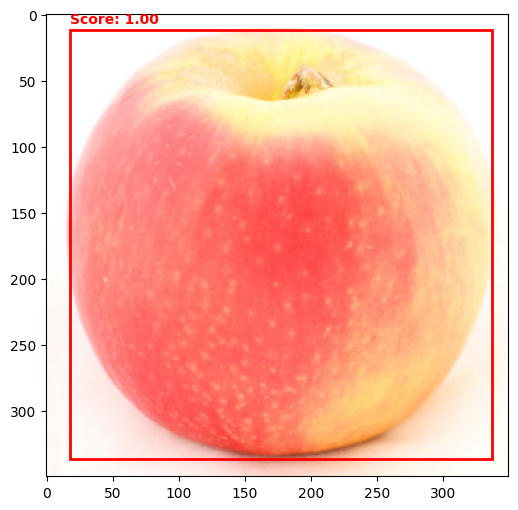

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a test image
test_image_path = os.path.join(test_dir, "apple_78.jpg")  # Change filename
image, _, _ = load_image_and_annotation(test_image_path)

# Transform & run inference
image_tensor = transform(image).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    predictions = model(image_tensor)

# Extract predictions
boxes = predictions[0]['boxes'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()

# Plot results
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(image)

for i, (box, score) in enumerate(zip(boxes, scores)):
    if score > 0.5:  # Confidence threshold
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, f"Score: {score:.2f}", color='red', fontsize=10, weight='bold')

plt.show()


In [ ]:
# Lower learning rate
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

# Increase batch size
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [ ]:
# Training Loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 4.4855
Epoch [2/5], Loss: 4.0453
Epoch [3/5], Loss: 3.8598
Epoch [4/5], Loss: 3.7411
Epoch [5/5], Loss: 3.6577


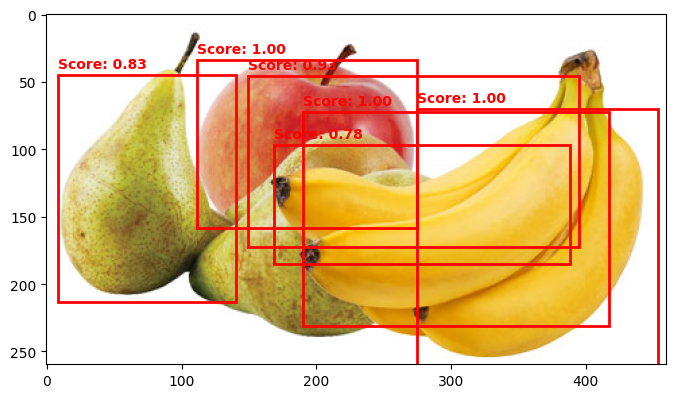

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a test image
test_image_path = os.path.join(test_dir, "mixed_24.jpg")  # Change filename
image, _, _ = load_image_and_annotation(test_image_path)

# Transform & run inference
image_tensor = transform(image).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    predictions = model(image_tensor)

# Extract predictions
boxes = predictions[0]['boxes'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()

# Plot results
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(image)

for i, (box, score) in enumerate(zip(boxes, scores)):
    if score > 0.5:  # Confidence threshold
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, f"Score: {score:.2f}", color='red', fontsize=10, weight='bold')

plt.show()


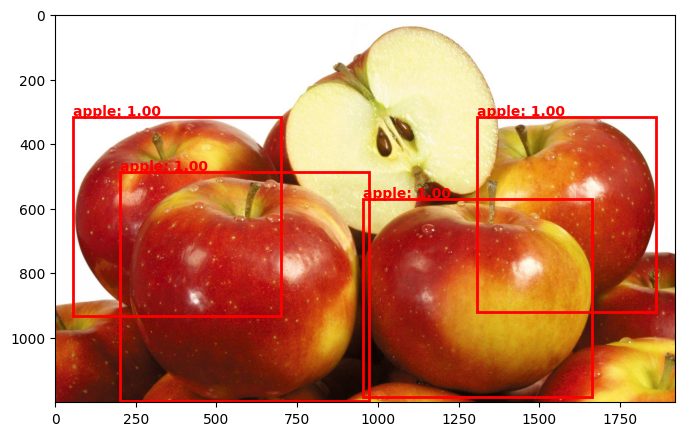

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define class names (Modify this based on your dataset)
class_names = ["__background__", "apple", "banana", "orange"]  # Example classes

# Load a test image
test_image_path = os.path.join(test_dir, "apple_95.jpg")  # Change filename
image, _, _ = load_image_and_annotation(test_image_path)

# Transform & run inference
image_tensor = transform(image).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    predictions = model(image_tensor)

# Extract predictions
boxes = predictions[0]['boxes'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()
labels = predictions[0]['labels'].cpu().numpy()  # Class labels

# Plot results
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(image)

for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
    if score > 0.5:  # Confidence threshold
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Get class name from labels
        class_name = class_names[label] if label < len(class_names) else "Unknown"

        ax.text(x_min, y_min - 5, f"{class_name}: {score:.2f}", color='red', fontsize=10, weight='bold')

plt.show()
